In [26]:
from datetime import datetime
from pathlib import Path
import yaml
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from get_collections_and_files import list_files_and_excluded_vars

LEV_NAMES = ["lev", "level", "pressure"]
LAT_NAMES = ["lat", "latitude", "y"]

def load_strata(strata_file: str | Path):
    with open(strata_file, "r") as f:
        return yaml.safe_load(f)["STRATA"]

def pick_name(ds, names):
    return next((n for n in names if n in ds.coords), None)

def plot_id_key_slice(model: str, date: str, id_key: str, data_yaml_file: str, strata_file: str):
    # id_key = "collection|var|lev_val|stratum"
    coll, var, lev_str, sname = id_key.split("|", 3)
    lev_val = None if lev_str == "None" else lev_str  # keep as string; xarray can match numbers too

    dt = datetime.strptime(date, "%Y-%m-%d")
    _, collection_dict, excluded = list_files_and_excluded_vars(model=model, date=dt, data_yaml_file=data_yaml_file)
    strata = load_strata(strata_file)

    ds = xr.open_mfdataset(
        collection_dict[coll],
        combine="by_coords",
        drop_variables=excluded,
        data_vars="minimal",
        coords="minimal",
        compat="no_conflicts",
        engine="h5netcdf",
        chunks="auto",
        parallel=True,
    )

    lat = pick_name(ds, LAT_NAMES)
    lev = pick_name(ds, LEV_NAMES)

    da = ds[var]
    if lev_val is not None and lev and lev in da.coords:
        da = da.sel({lev: lev_val})

    lat_min, lat_max = strata[sname]["lat"]["min"], strata[sname]["lat"]["max"]
    lat_arr = ds[lat].values
    lat_slice = slice(lat_min, lat_max) if np.all(np.diff(lat_arr) > 0) else slice(lat_max, lat_min)
    da = da.sel({lat: lat_slice})

    if "time" in da.dims:
        da = da.isel(time=0)

    arr = da.squeeze()

    plt.figure()
    if arr.ndim == 1:
        x = arr[arr.dims[0]].values if arr.dims[0] in arr.coords else np.arange(arr.size)
        plt.plot(x, arr.values)
        plt.xlabel(arr.dims[0])
        plt.ylabel(var)
    else:
        plt.pcolormesh(arr.values, shading="auto")
        plt.colorbar(label=var)
    plt.title(f"{model} {date}\n{id_key}")
    plt.tight_layout()
    plt.show()

# Example:


GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M05/D10


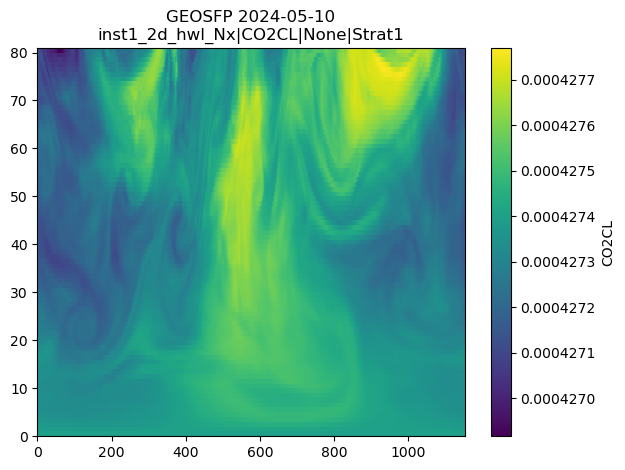

done


In [27]:
plot_id_key_slice(
     model="GEOSFP",
     date="2024-05-10",
     id_key="inst1_2d_hwl_Nx|CO2CL|None|Strat1",
     data_yaml_file="/home/sadhika8/JupyterLinks/nobackup/quads/conf/dataserver.yaml",
     strata_file="/home/sadhika8/JupyterLinks/nobackup/quads/conf/strata.yaml",
)
print("done")

In [28]:
import numpy as np
#import matplotlib.pyplot as plt
#from lowm_para_serial_for_users.py import load_quantiles_from_db

from pathlib import Path
import sqlite3
import pickle


def inspect_table(db_path : Path, model: str, n: int = 1):
    table = model.lower()
    with sqlite3.connect(str(db_path)) as conn:
        cols = [r[1] for r in conn.execute(f"PRAGMA table_info({table})").fetchall()]
        count = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        sample = conn.execute(f"SELECT * FROM {table} LIMIT ?", (n,)).fetchall()
    return {"table": table, "n_rows": count, "columns": cols, "sample_rows": sample}
db_path = "/home/sadhika8/JupyterLinks/nobackup/quads_database/geosfp_monthly_aggregated_centroids_and_quantiles.db"

#inspect_table(db_path, "geosfp")


In [29]:
def load_quantiles_from_db(db_path: Path, model: str, year: int, month: int, id_string: str):
    table = model.lower()
    with sqlite3.connect(str(db_path)) as conn:
        row = conn.execute(
            f"SELECT quantiles, quantile_list FROM {table} "
            "WHERE model=? AND year=? AND month=? AND id_string=?",
            (model, year, month, id_string),
        ).fetchone()

    if row is None:
        print("Not Found")
        return None

    return pickle.loads(row[0]), pickle.loads(row[1])


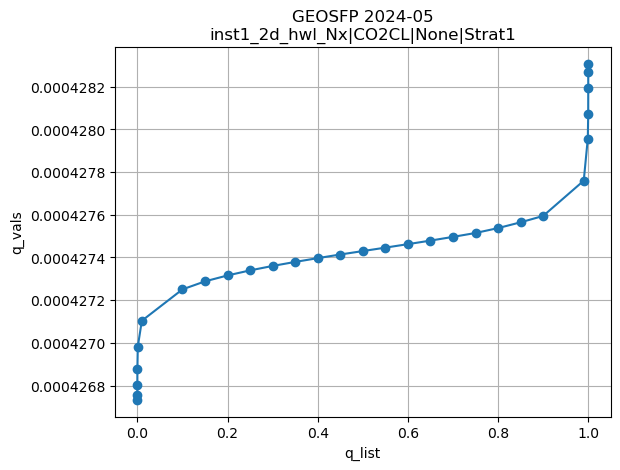

In [30]:
def plot_qcurve_from_db(db_path, model, year, month, id_key):
    ref = load_quantiles_from_db(db_path, model, year, month, id_key)

    if ref is None:
        return

    q_vals, q_list = ref

    q_vals = np.asarray(q_vals)
    q_list = np.asarray(q_list)

    plt.figure()
    plt.plot(q_list, q_vals, marker="o")
    plt.xlabel("q_list")
    plt.ylabel("q_vals")
    plt.title(f"{model} {year}-{month:02d}\n{id_key}")
    plt.grid(True)
    plt.show()


# Example:
plot_qcurve_from_db(
    db_path=Path("/home/sadhika8/JupyterLinks/nobackup/quads_database/geosfp_monthly_aggregated_centroids_and_quantiles.db"),
    model="GEOSFP",   # IMPORTANT: must match table name in your SQL query - tablename is capitalized!
    year=2024,
    month=5,
    id_key="inst1_2d_hwl_Nx|CO2CL|None|Strat1",
)
